## Learning Notebook: From Logistic Regression to Neural Networks (CIFAR-10)

### Overview

This notebook is both an **exercise and a learning resource**. It will guide you through applying **logistic regression** and a **basic neural network** to the **CIFAR-10 image classification dataset**. You'll explore how neural networks build on classical techniques and why they perform better on complex data like images.

### Context

This notebook highlights the most important steps to build a very simple fully conntected Neural Network with couple of layers. You will have to prepare the data for the model, apply the right loss function, and the right optimizer. 

### Goal:
- Train a logistic regression classifier on CIFAR-10 using flattened image vectors
- Train a neural network with at least one hidden layer and compare its performance
- Experiment with different learning rates and compare the results
- Visualize and interpret confusion matrices and train/test loss curves
- (Optional) Experiment with different hidden layer sizes and observe how accuracy changes
- (Optional) Add a second hidden layer and evaluate the impact
- (Optional) try to add learning rate decay and dropout

Follow the Jupyter notebook below and answer the tasks marked as ✅ Task for Students.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

### Read and process the data

In [6]:
# Load CIFAR-10 dataset 

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [7]:
# flatten the output class 
y_train = y_train.flatten()
y_test = y_test.flatten()

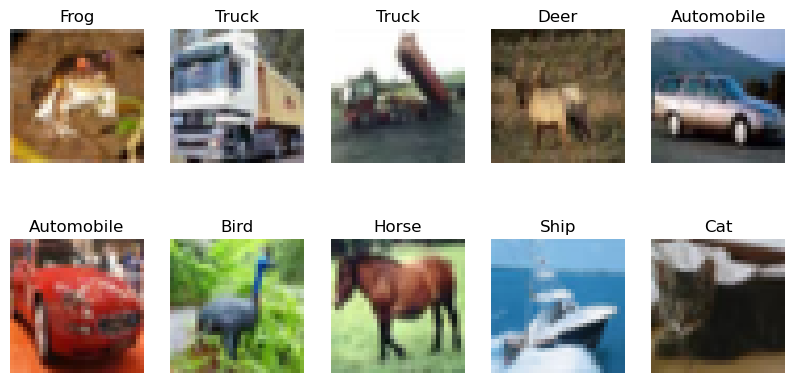

In [8]:
# Visualize Some input images with their classes
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [9]:
# Normalize the input vectors (min-max scaling)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
# Flatten the input since we will work with pixel values in the shape of vectors as input to FCNN
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [11]:
# One-hot encoding needed for the softmax function of the neural network
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


### Build and train a logistic regression model

✅ Task for students: complete the following code by building a Logistic Regression using sklearn functions, train for 100 iterations.

In [12]:
# Subsample for logistic regression
n_samples = 1000  # or 1000 for faster results
MAX_ITER = 500 # or 500 for faster results


# split to train and test
# your code here
index= np.random.choice(X_test_flat.shape[0], n_samples, replace=False)
X_sub , y_sub= X_train_flat[index], y_train[index]
X_sub_train, X_sub_test, y_sub_train, y_sub_test=train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

# code the logistic regression model and train it for 500 iterations
# your code here
logisticreg=LogisticRegression(max_iter=MAX_ITER)
logisticreg.fit(X_sub_train, y_sub_train)

/Users/mortega/miniconda3/envs/DataMining/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500)

✅ Task for students: print the classification report on the complete test data and on the complete train data. Are the results better than random classifier?

In [13]:
y_train_pred_log = logisticreg.predict(X_train_flat)
y_test_pred_log = logisticreg.predict(X_test_flat)

print(
    "Train data repot:\n", classification_report(y_train, y_train_pred_log)
)

print(
    "Test data repot:\n", classification_report(y_test, y_test_pred_log)
)

Train data repot:
               precision    recall  f1-score   support

           0       0.35      0.38      0.37      5000
           1       0.41      0.27      0.32      5000
           2       0.21      0.30      0.25      5000
           3       0.21      0.23      0.22      5000
           4       0.22      0.28      0.24      5000
           5       0.26      0.23      0.24      5000
           6       0.35      0.29      0.31      5000
           7       0.34      0.27      0.30      5000
           8       0.34      0.38      0.35      5000
           9       0.41      0.32      0.36      5000

    accuracy                           0.29     50000
   macro avg       0.31      0.29      0.30     50000
weighted avg       0.31      0.29      0.30     50000

Test data repot:
               precision    recall  f1-score   support

           0       0.34      0.37      0.35      1000
           1       0.38      0.23      0.29      1000
           2       0.20      0.27      0.

✅ Task for students: plot the Confusion Matrices for the logistic regression 

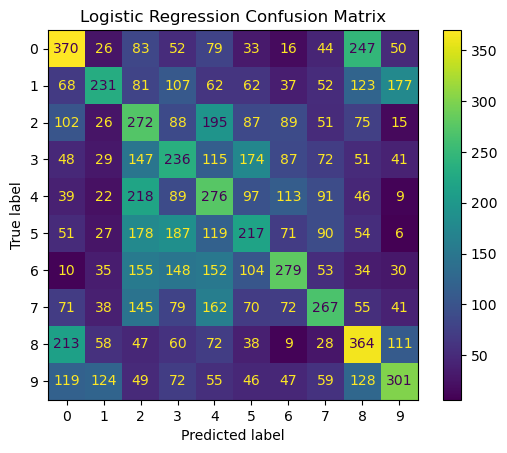

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Build and train a Neural Network

### Build the neural network model

The model can contain several hidden layers, and as it generates **multinomial classifications** of the input images, we need to apply the **softmax function** to the output logits. 


### Neural Network Architecture Summary

Build  a **simple feedforward neural network** for image classification on CIFAR-10. Add the following layers:

1. **Input Layer (Flatten)**

   * Converts each input image from shape **(32, 32, 3)** into a **1D vector of size 3072** (32 × 32 × 3).
   * This prepares the image data for fully connected layers.

2. **Hidden Layer (Dense)**

   * A fully connected layer with **128 neurons**.
   * Uses the **ReLU** activation function to introduce non-linearity.

3. **Output Layer (Dense)**

   * A fully connected layer with **10 neurons**, one for each class in CIFAR-10.
   * Uses **softmax** activation to output a probability distribution over the 10 classes.


#### What is the Softmax Function?

The **softmax function** is a normalized exponential function that maps a vector of continuous values (logits) into a vector of probabilities, ensuring that:
- All probabilities are non-negative.
- The sum of the probabilities equals 1.

#### Softmax Equation
The softmax function is defined as:

$$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{N} e^{z_j}}$$

Where:
- \( $z_i$): Logit (input to the softmax function) for class (i).
- \( $N$): Total number of classes.
- \( $e^{z_i}$): Exponential of the logit for class (i).
- \( $\sigma(z_i)$): Probability for class (i).

---

#### Example Input and Output

Let’s consider a vector of logits \( z \) for a 10-class problem:


$$z = [2.0, 1.0, 0.1, -1.0, 0.5, -0.2, 1.5, -0.5, 0.3, -1.5]$$

Using the softmax function, we calculate the probabilities:

1. Compute ($e^{z_i}$) for each ( $z_i$):

   $$e^z = [7.39, 2.72, 1.11, 0.37, 1.65, 0.82, 4.48, 0.61, 1.35, 0.22]$$


2. Compute the sum of all exponentials:

   $$\text{Sum} = 20.72$$

3. Normalize each exponential by dividing by the sum:

   $$\sigma(z) = \frac{e^z}{\text{Sum}} = [0.356, 0.131, 0.054, 0.018, 0.080, 0.039, 0.216, 0.030, 0.065, 0.011]$$

#### Final Probabilities
The output probabilities are:

$$[0.356, 0.131, 0.054, 0.018, 0.080, 0.039, 0.216, 0.030, 0.065, 0.011]$$

These probabilities sum up to 1 and can be interpreted as the likelihood of the input belonging to each class.

--- 

#### Use in Classification
The class with the highest probability (e.g., $\text{argmax}(\sigma(z))$) is the predicted class.


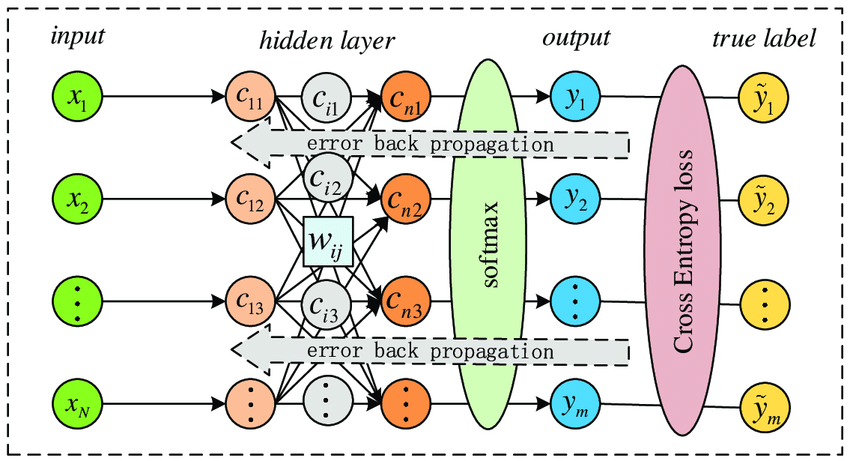

Zhou, Yangfan & Zhang, Mingchuan & Zhu, Junlong & Zheng, Ruijuan & Wu, Qingtao. (2019). MPCE: A Maximum Probability Based Cross Entropy Loss Function for Neural Network Classification. IEEE Access. PP. 1-1. 10.1109/ACCESS.2019.2946264. 

✅ Task for students: read the instructions above and code the mdoel using keras functions

In [15]:
# your code here
model = Sequential([Flatten(input_shape=(32,32,3)),
                    Dense(128,activation="relu"),
                    Dense(10, activation="softmax")])
model.summary()

/Users/mortega/miniconda3/envs/DataMining/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

### Define the cost Function for Multinomial Classification in CIFAR-10


#### **Why Use `CategoricalCrossentropy`?**
   - CIFAR-10 is a dataset consisting of images belonging to **10 distinct classes**. For such problems, a multinomial (or multi-class) classification approach is required.
   - `CategoricalCrossentropy` is the standard loss function for measuring the difference between the predicted probability distribution over classes and the true class labels (one-hot encoded).

#### **Mathematical Explanation**
The `CategoricalCrossentropy` loss is calculated as:


$$ \text{Loss} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{i,j} \cdot \log(\hat{y}_{i,j}) $$

Where:
- (N): Number of examples in the batch.
- (C): Number of classes (10 for CIFAR-10).
- ($y_{i,j}$): True label for class \(j\) (one-hot encoded: 1 for the correct class, 0 otherwise).
- \($hat{y}_{i,j}$): Predicted probability for class (j).

This formula penalizes the model more heavily when it assigns low probability to the correct class.

### Define the optimizer we want to use to find the model parameters during the training

#### **What is `SGD`?**

Stochastic Gradient Descent is a faster, more scalable version of standard Gradient Descent optimizer.  Instead of computing gradients on the entire dataset (as in GD), SGD updates model weights using just one training example (or a small batch) at a time.

#### **Why use it?**
- Faster updates → learns faster in early training

- Adds noise → helps escape local minima and explore better solutions

- Scales well to large datasets where full-batch GD is too slow

✅ Task for students: read the instructions above and add an SGD optimizer with 0.01 learning rate and a loss function for your NN model

In [24]:
from tensorflow.keras.optimizers import SGD
sgd=SGD(learning_rate=0.1)
model.compile(optimizer=sgd,loss="categorical_crossentropy", metrics=["accuracy"])

# your code here


✅ Task for students: train the model for 50 epochs and plot how the test and train loss change during the training

In [25]:
# train/fit the model 
# your code here
history=model.fit(X_train, y_train_cat,validation_data=(X_test, y_test_cat),epochs=50)


Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.2306 - loss: 2.5906 - val_accuracy: 0.2485 - val_loss: 2.2397
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.3130 - loss: 1.8805 - val_accuracy: 0.2570 - val_loss: 2.2465
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.3530 - loss: 1.7984 - val_accuracy: 0.3132 - val_loss: 1.8754
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step - accuracy: 0.3677 - loss: 1.7502 - val_accuracy: 0.3407 - val_loss: 1.7909
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - accuracy: 0.3822 - loss: 1.7237 - val_accuracy: 0.3783 - val_loss: 1.7255
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - accuracy: 0.3885 - loss: 1.7006 - val_accuracy: 0.3287 - val_loss: 1.8893
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.4006 - loss: 1.6689 - val_accuracy: 0.3884 - val_loss: 1.6798
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.4050 -

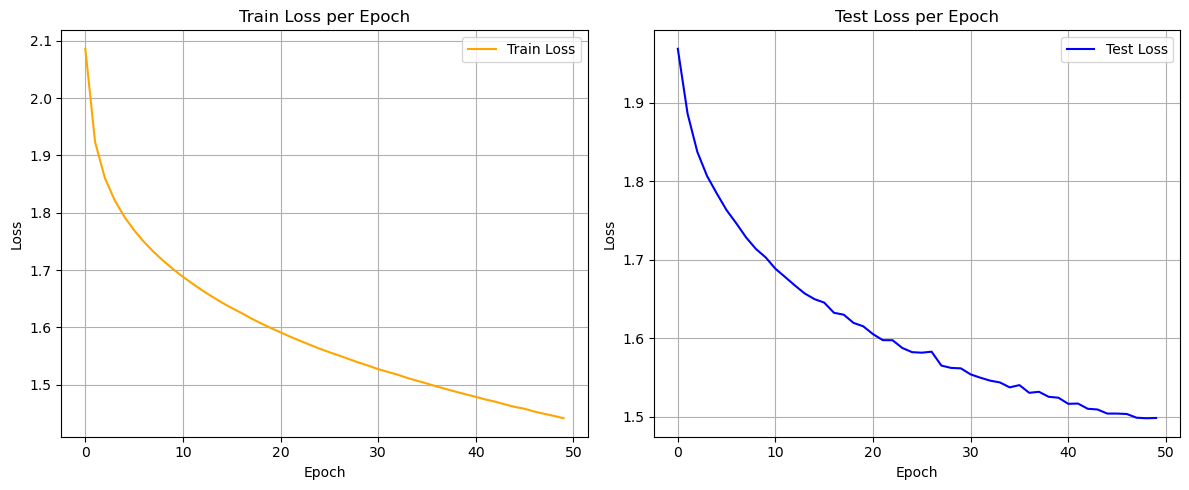

In [18]:
# plot the training by create side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Train Loss
axs[0].plot(history.history['loss'], label='Train Loss', color='orange')
axs[0].set_title('Train Loss per Epoch')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot Test (Validation) Loss
axs[1].plot(history.history['val_loss'], label='Test Loss', color='blue')
axs[1].set_title('Test Loss per Epoch')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

✅ Task for students: try different learning rates, 0.001, 0.01, 0.1 and explain what happened to the models train and test error. Write your observation below.

🔁 Remember: You must rebuild and recompile the model before training with each new learning rate. Reusing the same model can lead to misleading results.

In [19]:
answer = """
# your answer here
"""

✅ Task for students: predict class labels for the test data and print the classification report (remember that your models' output is a vector)

In [26]:
# Predict class labels
# your code here
predictions=model.predict(X_test)
neural_predictions=np.argmax(predictions, axis=1)
print(classification_report(y_test,neural_predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step
              precision    recall  f1-score   support

           0       0.54      0.42      0.47      1000
           1       0.70      0.36      0.47      1000
           2       0.30      0.29      0.30      1000
           3       0.25      0.59      0.35      1000
           4       0.42      0.37      0.39      1000
           5       0.37      0.10      0.16      1000
           6       0.37      0.57      0.45      1000
           7       0.55      0.47      0.50      1000
           8       0.62      0.44      0.51      1000
           9       0.49      0.54      0.51      1000

    accuracy                           0.41     10000
   macro avg       0.46      0.41      0.41     10000
weighted avg       0.46      0.41      0.41     10000



✅ Task for students: plot the Confusion Matrices for the neural network

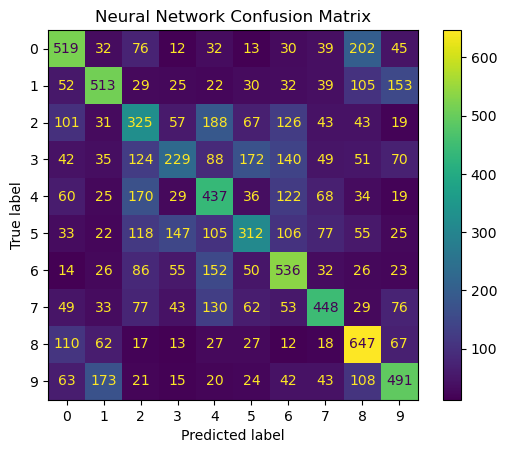

In [ ]:
# your code here
